Causal Machine Learning for Identifying Determinants of Flood Occurrence: Evidence from Infrastructure Interventions

In [2]:
# Syep 1:
!pip install econml shap xgboost lightgbm

  Using cached econml-0.16.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (37 kB)
  Using cached sparse-0.18.0-py2.py3-none-any.whl.metadata (5.3 kB)
  Using cached shap-0.48.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (25 kB)
Using cached econml-0.16.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (5.4 MB)
Using cached shap-0.48.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.0 MB)
Using cached sparse-0.18.0-py2.py3-none-any.whl (151 kB)
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


In [3]:
# Step 2:
import pandas as pd
import numpy as np
np.random.seed(42)

df = pd.read_csv("flood_risk_dataset_india.csv")

print(df.head())

    Latitude  Longitude  Rainfall (mm)  Temperature (C)  Humidity (%)  \
0  18.861663  78.835584     218.999493        34.144337     43.912963   
1  35.570715  77.654451      55.353599        28.778774     27.585422   
2  29.227824  73.108463     103.991908        43.934956     30.108738   
3  25.361096  85.610733     198.984191        21.569354     34.453690   
4  12.524541  81.822101     144.626803        32.635692     36.292267   

   River Discharge (m3/s)  Water Level (m)  Elevation (m)    Land Cover  \
0             4236.182888         7.415552     377.465434    Water Body   
1             2472.585219         8.811019    7330.608875        Forest   
2              977.328053         4.631799    2205.873488  Agricultural   
3             3683.208933         2.891787    2512.277800        Desert   
4             2093.390678         3.188466    2001.818223  Agricultural   

  Soil Type  Population Density  Infrastructure  Historical Floods  \
0      Clay         7276.742184         

In [4]:
# Step 3:
# Basic info
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nFirst 5 rows:")
df.head()

Shape of dataset: (10000, 14)

Column names:
Index(['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (C)',
       'Humidity (%)', 'River Discharge (m3/s)', 'Water Level (m)',
       'Elevation (m)', 'Land Cover', 'Soil Type', 'Population Density',
       'Infrastructure', 'Historical Floods', 'Flood Occurred'],
      dtype='object')

First 5 rows:


,Latitude,Longitude,Rainfall (mm),Temperature (C),Humidity (%),River Discharge (m3/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465434,Water Body,Clay,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0


In [5]:
# Step 4:
# Define outcome
Y = df["Flood Occurred"]

# Define treatment
T = df["Infrastructure"]

# Define confounders (exclude outcome and treatment)
X = df.drop(columns=["Flood Occurred", "Infrastructure"])

print("Outcome shape:", Y.shape)
print("Treatment shape:", T.shape)
print("Confounders shape:", X.shape)

X.head()

Outcome shape: (10000,)
Treatment shape: (10000,)
Confounders shape: (10000, 12)


,Latitude,Longitude,Rainfall (mm),Temperature (C),Humidity (%),River Discharge (m3/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Historical Floods
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465434,Water Body,Clay,7276.742184,0
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,1
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,0


In [6]:
# Step 5:
# Convert categorical variables to numerical using one-hot encoding
categorical_cols = ["Land Cover", "Soil Type"]
X_encoded = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True)

print("New feature shape:", X_encoded.shape)
X_encoded.head()

New feature shape: (10000, 18)


,Latitude,Longitude,Rainfall (mm),Temperature (C),Humidity (%),River Discharge (m3/s),Water Level (m),Elevation (m),Population Density,Historical Floods,Land Cover_Desert,Land Cover_Forest,Land Cover_Urban,Land Cover_Water Body,Soil Type_Loam,Soil Type_Peat,Soil Type_Sandy,Soil Type_Silt
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465434,7276.742184,0,False,False,False,True,False,False,False,False
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,6897.736956,1,False,True,False,False,False,True,False,False
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,4361.518494,1,False,False,False,False,True,False,False,False
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,6163.069701,1,True,False,False,False,False,False,True,False
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,6167.964591,0,False,False,False,False,True,False,False,False


In [7]:
# Step 6:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert True/False columns to numeric
X_encoded = X_encoded.astype(float)

# Train-test split
X_train, X_test, Y_train, Y_test, T_train, T_test = train_test_split(
    X_encoded, Y, T, test_size=0.3, random_state=42
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape)
print("Testing samples:", X_test_scaled.shape)

Training samples: (7000, 18)
Testing samples: (3000, 18)


In [8]:
# Step 7:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier

# Define outcome model
model_y = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

# Define treatment model
model_t = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

In [9]:
# Step 8:

# Ensure binary integer values
Y_train = Y_train.astype(int)
T_train = T_train.astype(int)

# Outcome model
model_y = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

# Treatment model
model_t = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

# Causal Forest model
cf = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_outcome=True,
    discrete_treatment=True,
    n_estimators=500,
    min_samples_leaf=20,
    max_depth=10,
    cv=5,
    random_state=42
)

# Fit model using scaled features
cf.fit(Y_train, T_train, X=X_train_scaled)

# Estimate treatment effects
treatment_effects = cf.effect(X_test_scaled)

print("First 10 treatment effects:")
print(treatment_effects[:10])

print("Average Treatment Effect:", np.mean(treatment_effects))

First 10 treatment effects:
[[ 0.01987585]
 [-0.01784238]
 [-0.00321245]
 [-0.02263981]
 [-0.03768543]
 [-0.04976368]
 [-0.03058464]
 [-0.01137667]
 [-0.03593488]
 [ 0.00946856]]
Average Treatment Effect: -0.015654426475886996


In [10]:
# Step 9:
# Train causal forest with scaled features
cf.fit(Y_train, T_train, X=X_train_scaled)

# Estimate treatment effects
treatment_effects = cf.effect(X_test_scaled)

print("First 10 treatment effects:")
print(treatment_effects[:10])

First 10 treatment effects:
[[ 0.01987585]
 [-0.01784238]
 [-0.00321245]
 [-0.02263981]
 [-0.03768543]
 [-0.04976368]
 [-0.03058464]
 [-0.01137667]
 [-0.03593488]
 [ 0.00946856]]


In [11]:
# STEP 10: Calculate Average Treatment Effect (ATE)

ate = np.mean(treatment_effects)

print("Average Treatment Effect (ATE):", ate)

Average Treatment Effect (ATE): -0.015654426475886992


In [12]:
# STEP 11: Create dataframe with treatment effects
results = X_test.copy()
results["Treatment Effect"] = treatment_effects

# show first rows
results.head()

,Latitude,Longitude,Rainfall (mm),Temperature (C),Humidity (%),River Discharge (m3/s),Water Level (m),Elevation (m),Population Density,Historical Floods,Land Cover_Desert,Land Cover_Forest,Land Cover_Urban,Land Cover_Water Body,Soil Type_Loam,Soil Type_Peat,Soil Type_Sandy,Soil Type_Silt,Treatment Effect
6252,17.786834,70.809873,290.684548,32.380421,69.941956,2149.788641,3.760597,5732.622500,6560.217327,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.019876
4684,30.489654,90.892009,58.531742,38.362878,58.367639,4072.418785,7.698761,7382.350078,4459.140280,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.017842
1731,26.092979,74.056274,296.806505,32.078594,21.928201,923.416760,0.560510,7186.187445,8658.024273,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,-0.003212
4742,9.032117,91.371264,38.474462,24.974476,76.301193,3350.129157,5.704189,8430.156974,7620.791748,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.022640
4521,24.736395,95.315406,106.425281,40.369730,68.557714,4741.233104,6.884878,3253.443151,6311.284520,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.037685


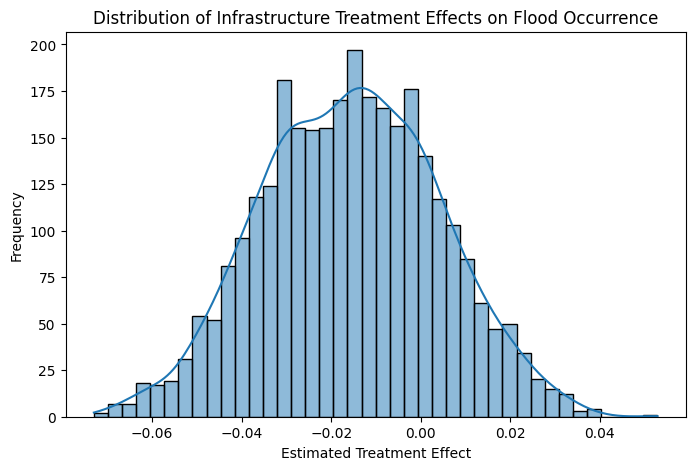

In [13]:
# STEP 12: Plot distribution of causal effects

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(results["Treatment Effect"], bins=40, kde=True)

plt.title("Distribution of Infrastructure Treatment Effects on Flood Occurrence")
plt.xlabel("Estimated Treatment Effect")
plt.ylabel("Frequency")

plt.show()

In [14]:
# STEP 13: Compare treatment effect by rainfall levels

results["Rainfall Category"] = pd.qcut(results["Rainfall (mm)"], q=4, labels=[
    "Low Rainfall",
    "Moderate Rainfall",
    "High Rainfall",
    "Extreme Rainfall"
])

rainfall_effect = results.groupby("Rainfall Category")["Treatment Effect"].mean()

print(rainfall_effect)

Rainfall Category
Low Rainfall        -0.010778
Moderate Rainfall   -0.016813
High Rainfall       -0.016865
Extreme Rainfall    -0.018162
Name: Treatment Effect, dtype: float64


/tmp/ipykernel_707/1954983740.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rainfall_effect = results.groupby("Rainfall Category")["Treatment Effect"].mean()


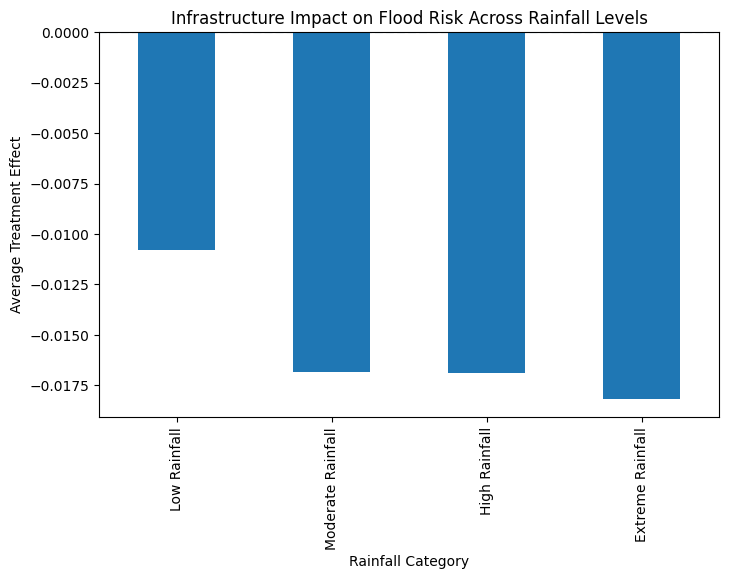

In [15]:
# STEP 14: Visualize treatment effect by rainfall category

rainfall_effect.plot(kind='bar', figsize=(8,5))

plt.title("Infrastructure Impact on Flood Risk Across Rainfall Levels")
plt.xlabel("Rainfall Category")
plt.ylabel("Average Treatment Effect")

plt.axhline(0, linestyle='--')

plt.show()

In [16]:
# STEP 15: Feature importance from the causal forest

# Extract feature importance from Causal Forest
feature_importance = np.array(cf.feature_importances_)

# Build importance table
causal_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
})

# Sort by importance
causal_importance = (
    causal_importance
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

# Display top causal drivers
print("Top 10 Causal Drivers:")
print(causal_importance.head(10))

Top 10 Causal Drivers:
                  Feature  Importance
0         Water Level (m)    0.143997
1               Longitude    0.134433
2         Temperature (C)    0.115011
3           Rainfall (mm)    0.106478
4            Humidity (%)    0.100425
5  River Discharge (m3/s)    0.096050
6                Latitude    0.092880
7           Elevation (m)    0.083735
8      Population Density    0.083405
9       Land Cover_Desert    0.008867


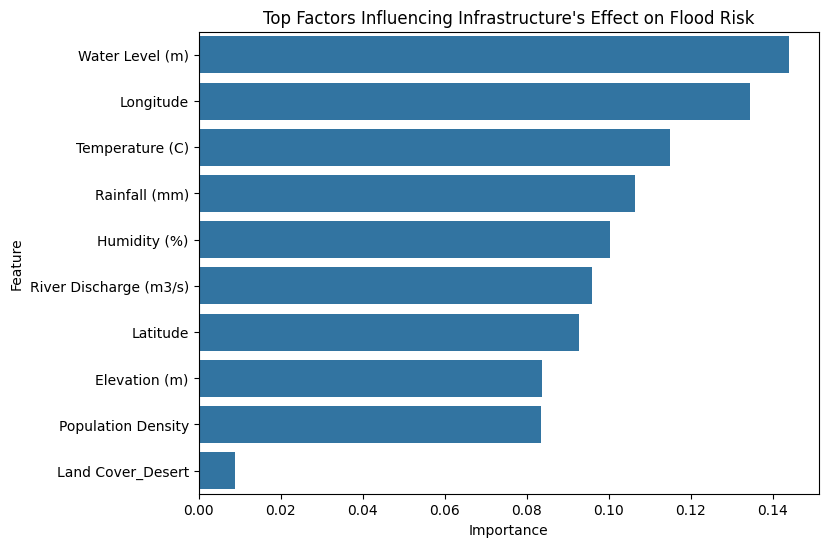

In [19]:
# STEP 16: Plot feature importance from the Causal Forest

plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=causal_importance.head(10)
)

plt.title("Top Factors Influencing Infrastructure's Effect on Flood Risk")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [20]:
# STEP 17: Confidence intervals for treatment effects

lower, upper = cf.effect_interval(X_test)

print("Lower bounds (first 10):")
print(lower[:10])

print("\nUpper bounds (first 10):")
print(upper[:10])

Lower bounds (first 10):
[-0.05929255 -0.06423522 -0.05851341 -0.05553204 -0.0575621  -0.06993862
 -0.06931697 -0.06778188 -0.05722944 -0.06055871]

Upper bounds (first 10):
[0.03682121 0.04209174 0.03514959 0.04243449 0.03400459 0.03692392
 0.03944622 0.03634802 0.03683445 0.04223644]


In [21]:
# STEP 18: Average Treatment Effect with confidence interval

ate = treatment_effects.mean()
ate_lower = lower.mean()
ate_upper = upper.mean()

print("Average Treatment Effect (ATE):", ate)
print("95% Confidence Interval:", (ate_lower, ate_upper))

Average Treatment Effect (ATE): -0.015654426475886992
95% Confidence Interval: (np.float64(-0.06011600793744388), np.float64(0.03740784423530502))


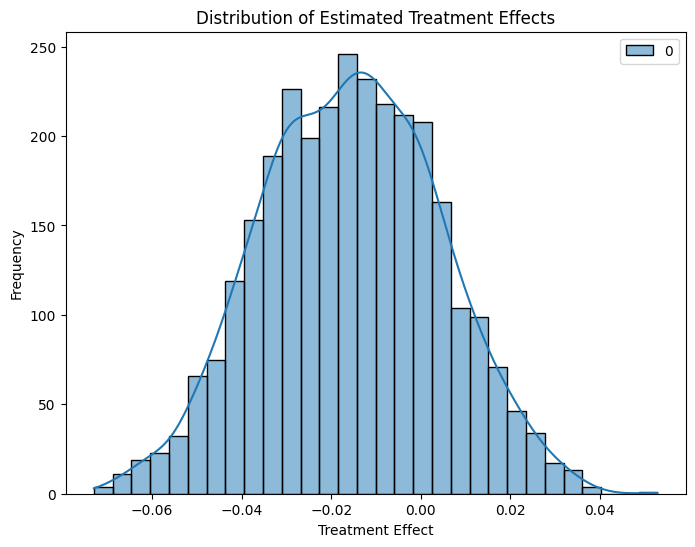

In [22]:
# STEP 19: Plot distribution of treatment effects

plt.figure(figsize=(8,6))

sns.histplot(treatment_effects, bins=30, kde=True)

plt.title("Distribution of Estimated Treatment Effects")
plt.xlabel("Treatment Effect")
plt.ylabel("Frequency")

plt.show()

In [23]:
# STEP 20: Placebo / Refutation Test

# Randomly shuffle treatment
T_random = np.random.permutation(T_train)

# Train placebo causal forest using SAME settings as main model
cf_placebo = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_outcome=True,
    discrete_treatment=True,
    n_estimators=500,
    min_samples_leaf=20,
    max_depth=10,
    cv=5,
    random_state=42
)

cf_placebo.fit(Y_train, T_random, X=X_train_scaled)

placebo_effects = cf_placebo.effect(X_test_scaled)


print("Placebo Average Treatment Effect:", np.mean(placebo_effects))

Placebo Average Treatment Effect: 0.021705906621579164


In [24]:
# STEP 21: Sensitivity analysis (remove rainfall variable)

# Remove rainfall variable
X_train_sens = X_train.drop(columns=["Rainfall (mm)"], errors="ignore")
X_test_sens = X_test.drop(columns=["Rainfall (mm)"], errors="ignore")

# Scale features again after removing column
scaler_sens = StandardScaler()

X_train_sens_scaled = scaler_sens.fit_transform(X_train_sens)
X_test_sens_scaled = scaler_sens.transform(X_test_sens)

# Train causal forest with same parameters
cf_sens = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_outcome=True,
    discrete_treatment=True,
    n_estimators=500,
    min_samples_leaf=20,
    max_depth=10,
    cv=5,
    random_state=42
)

cf_sens.fit(Y_train, T_train, X=X_train_sens_scaled)

# Estimate treatment effects
sens_effects = cf_sens.effect(X_test_sens_scaled)

print("ATE without rainfall variable:", sens_effects.mean())

ATE without rainfall variable: -0.017312239206346954


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
100%|===================| 2998/3000 [02:38<00:00]       /tmp/ipykernel_707/4197886829.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, feature_names=X_test.columns)


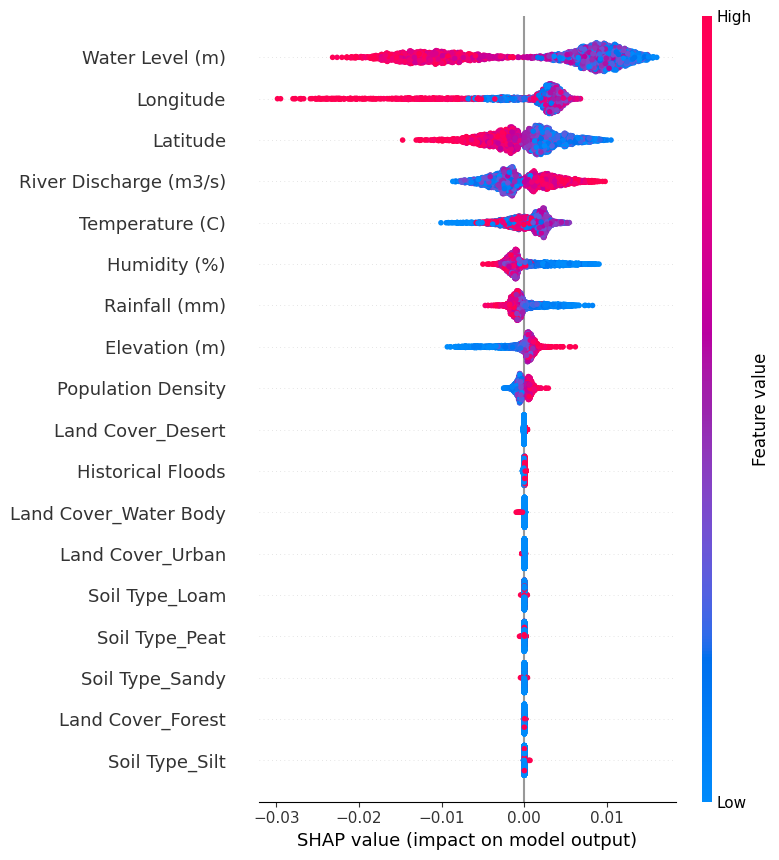

In [25]:
# STEP 22: SHAP interpretation for treatment effects
import shap
# Train surrogate model to approximate treatment effects
surrogate = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

surrogate.fit(X_test_scaled, treatment_effects)

# Create SHAP explainer
explainer = shap.Explainer(surrogate, X_test_scaled)

# Compute SHAP values
shap_values = explainer(X_test_scaled)

# Plot SHAP summary
shap.summary_plot(shap_values, X_test_scaled, feature_names=X_test.columns)

In [26]:
# STEP 23: Create policy zones based on treatment effects

results["Policy Zone"] = pd.cut(
    results["Treatment Effect"],
    bins=[-100, -0.02, -0.01, 0.01, 100],
    labels=[
        "High Infrastructure Benefit",
        "Moderate Infrastructure Benefit",
        "Neutral Impact",
        "Potential Risk Increase"
    ]
)

# Count observations in each zone
policy_counts = results["Policy Zone"].value_counts()

print(policy_counts)

Policy Zone
High Infrastructure Benefit        1250
Neutral Impact                      885
Moderate Infrastructure Benefit     562
Potential Risk Increase             303
Name: count, dtype: int64


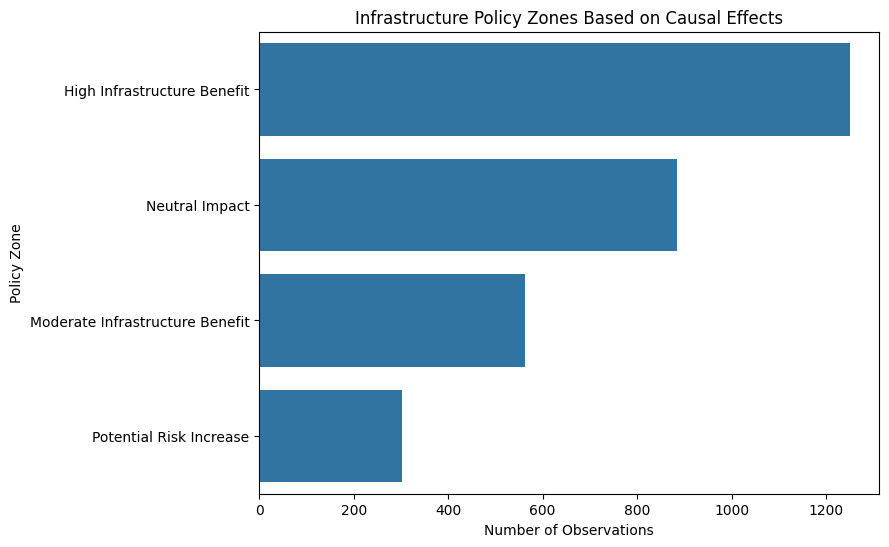

In [27]:
# STEP 24: Plot policy zone distribution

plt.figure(figsize=(8,6))

sns.countplot(
    data=results,
    y="Policy Zone",
    order=results["Policy Zone"].value_counts().index
)

plt.title("Infrastructure Policy Zones Based on Causal Effects")
plt.xlabel("Number of Observations")
plt.ylabel("Policy Zone")

plt.show()

In [28]:
# STEP 25: Counterfactual infrastructure scenario

# Counterfactual: assume all regions receive infrastructure
T0 = np.zeros_like(T_test)   # no infrastructure
T1 = np.ones_like(T_test)    # infrastructure added

# Estimate counterfactual effect
counterfactual_effect = cf.effect(X_test_scaled, T0=T0, T1=T1)

print("Average Counterfactual Effect (Infrastructure vs No Infrastructure):")
print(counterfactual_effect.mean())

Average Counterfactual Effect (Infrastructure vs No Infrastructure):
-0.015654426475886996


In [29]:
# STEP 26: Cluster treatment effects

from sklearn.cluster import KMeans

# Reshape treatment effects for clustering
te_values = treatment_effects.reshape(-1, 1)

# Apply clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(te_values)

# Add cluster labels
results["Effect Cluster"] = clusters

# Count observations in each cluster
cluster_counts = results["Effect Cluster"].value_counts()

print(cluster_counts)

Effect Cluster
0    1246
1     946
2     808
Name: count, dtype: int64


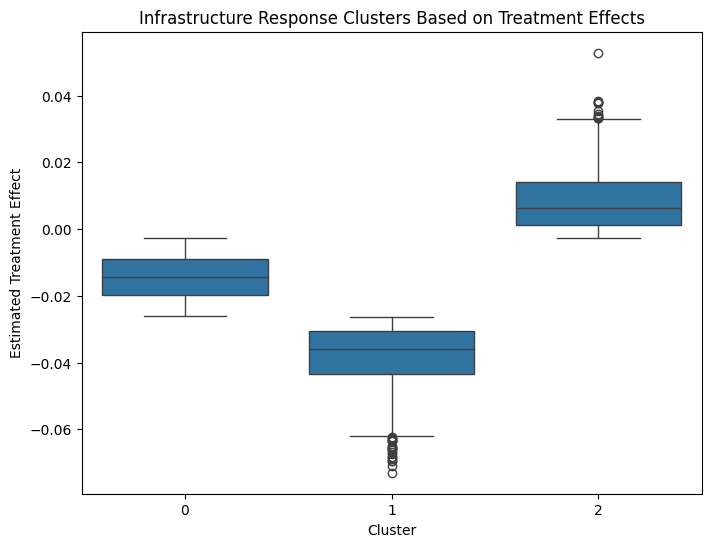

In [30]:
# STEP 27: Visualize treatment effect clusters


plt.figure(figsize=(8,6))

sns.boxplot(
    x="Effect Cluster",
    y="Treatment Effect",
    data=results
)

plt.title("Infrastructure Response Clusters Based on Treatment Effects")
plt.xlabel("Cluster")
plt.ylabel("Estimated Treatment Effect")

plt.show()

In [31]:
# STEP 28: Double Machine Learning validation

from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor

# Define models
model_y = RandomForestRegressor(n_estimators=100, random_state=42)
model_t = RandomForestRegressor(n_estimators=100, random_state=42)

# DML estimator
dml = LinearDML(model_y=model_y, model_t=model_t, random_state=42)

# Train model using scaled features
dml.fit(Y_train, T_train, X=X_train_scaled)

# Estimate treatment effects
dml_effects = dml.effect(X_test_scaled)

print("DML Average Treatment Effect:", dml_effects.mean())

DML Average Treatment Effect: -0.0166608355017216


In [32]:
# STEP 29: Rank areas by infrastructure benefit (uplift ranking)

# Add treatment effects to dataset
results["Uplift Score"] = treatment_effects

# Rank observations by uplift score
uplift_ranking = results.sort_values(by="Uplift Score")

# Show top 10 most beneficial areas
print("Top 10 areas benefiting most from infrastructure:")
print(uplift_ranking.head(10))

# Show 10 areas with lowest benefit
print("\nAreas with lowest or negative benefit:")
print(uplift_ranking.tail(10))

Top 10 areas benefiting most from infrastructure:
       Latitude  Longitude  Rainfall (mm)  Temperature (C)  Humidity (%)  \
9237  10.915380  72.029432     118.735184        22.378587     89.433719   
9977  32.075140  75.061682     204.059370        39.628782     98.731541   
551   32.713264  79.655063     144.624960        44.778764     59.655052   
2913  36.038519  71.379794     123.085713        18.484149     62.655026   
7557  22.729025  72.464869     158.135427        17.117089     73.095759   
8281  36.304585  75.659201      65.134515        43.086495     71.234575   
7927  33.041252  69.418443     113.556913        15.179245     69.218900   
5278  35.257807  78.328036      77.187770        42.428156     62.151085   
2540  27.097675  70.281826     261.033912        35.472141     51.766609   
3542  12.260736  69.527527     108.820145        17.116410     84.248150   

      River Discharge (m3/s)  Water Level (m)  Elevation (m)  \
9237             4364.264634         9.639466    

In [33]:
# STEP 30: Identify priority infrastructure investment zones

# Select top 20% areas with strongest flood-risk reduction
threshold = results["Uplift Score"].quantile(0.20)

priority_zones = results[results["Uplift Score"] <= threshold]

print("Number of priority investment zones:")
print(len(priority_zones))

print("\nSample of priority zones:")
print(priority_zones.head())

Number of priority investment zones:
600

Sample of priority zones:
       Latitude  Longitude  Rainfall (mm)  Temperature (C)  Humidity (%)  \
4521  24.736395  95.315406     106.425281        40.369730     68.557714   
6340  15.176426  68.041346     122.617779        25.928058     58.192405   
6363  21.624325  78.864940     117.634017        22.698007     95.460200   
2249  11.333057  96.132222       8.589511        24.473889     75.190619   
4947  29.507191  80.793164     278.061661        28.017675     64.126030   

      River Discharge (m3/s)  Water Level (m)  Elevation (m)  \
4521             4741.233104         6.884878    3253.443151   
6340             3682.827171         9.471104    1260.110425   
6363             4869.501427         8.012134    7401.662098   
2249             3034.982387         7.555770    5861.309951   
4947             2122.308602         9.354507     208.371258   

      Population Density  Historical Floods  ...  Land Cover_Water Body  \
4521         63

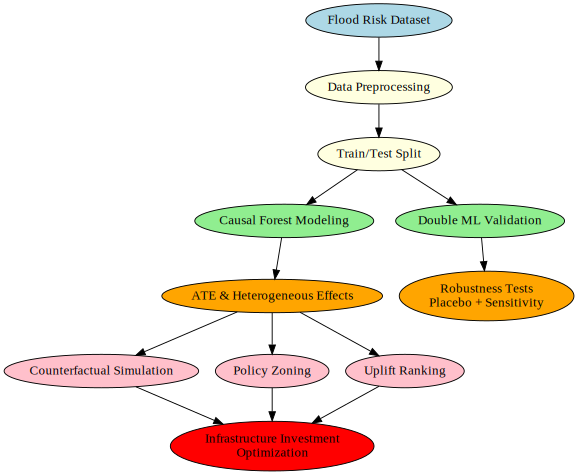

In [34]:
# STEP 31: Colored tree framework diagram

!pip install graphviz

from graphviz import Digraph
from IPython.display import display

g = Digraph('Flood Framework', format='png')

g.attr(rankdir='TB', size='8,8')

# Root
g.node('A', 'Flood Risk Dataset', style='filled', fillcolor='lightblue')

# Level 1
g.node('B', 'Data Preprocessing', style='filled', fillcolor='lightyellow')
g.node('C', 'Train/Test Split', style='filled', fillcolor='lightyellow')

# Level 2
g.node('D', 'Causal Forest Modeling', style='filled', fillcolor='lightgreen')
g.node('E', 'Double ML Validation', style='filled', fillcolor='lightgreen')

# Level 3
g.node('F', 'ATE & Heterogeneous Effects', style='filled', fillcolor='orange')
g.node('G', 'Robustness Tests\nPlacebo + Sensitivity', style='filled', fillcolor='orange')

# Level 4
g.node('H', 'Counterfactual Simulation', style='filled', fillcolor='pink')
g.node('I', 'Policy Zoning', style='filled', fillcolor='pink')
g.node('J', 'Uplift Ranking', style='filled', fillcolor='pink')

# Final
g.node('K', 'Infrastructure Investment\nOptimization', style='filled', fillcolor='red')

# Connections
g.edges([('A','B'),('B','C'),('C','D'),('C','E')])
g.edges([('D','F'),('E','G')])
g.edges([('F','H'),('F','I'),('F','J')])
g.edge('H','K')
g.edge('I','K')
g.edge('J','K')

display(g)

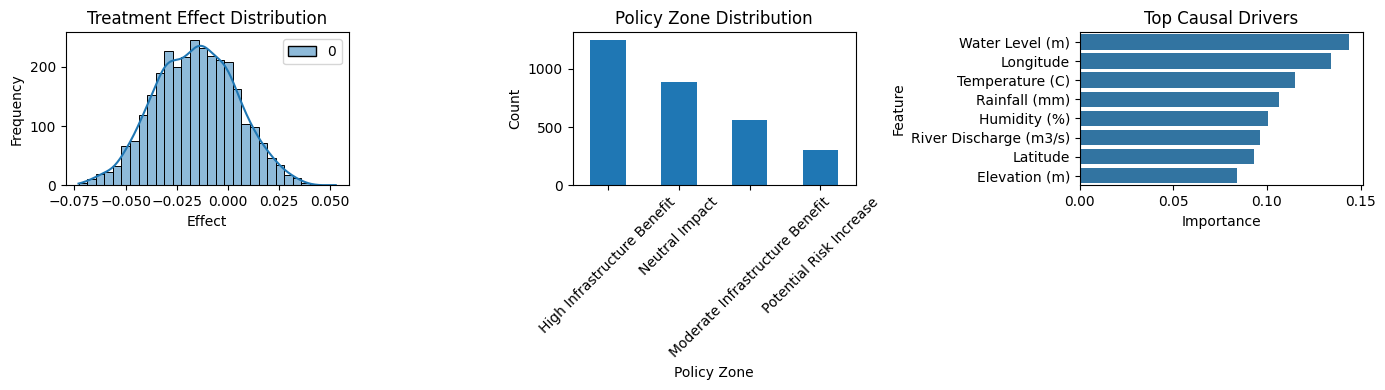

In [35]:
# STEP 32: Create results dashboard

plt.figure(figsize=(14,4))

# --- Panel 1: Treatment Effect Distribution ---
plt.subplot(1,3,1)
sns.histplot(treatment_effects, bins=30, kde=True)
plt.title("Treatment Effect Distribution")
plt.xlabel("Effect")
plt.ylabel("Frequency")

# --- Panel 2: Policy Zone Counts ---
plt.subplot(1,3,2)
results["Policy Zone"].value_counts().plot(kind="bar")
plt.title("Policy Zone Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)

# --- Panel 3: Top Causal Feature Importance ---
plt.subplot(1,3,3)
top_features = causal_importance.head(8)
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top Causal Drivers")

plt.tight_layout()
plt.show()

In [36]:
# STEP 33: Create summary results table

summary_table = pd.DataFrame({
    "Analysis": [
        "Average Treatment Effect",
        "Placebo Test Effect",
        "Sensitivity Analysis (No Rainfall)",
        "Counterfactual Effect (Infrastructure vs No Infrastructure)"
    ],
    "Estimated Value": [
        ate,
        placebo_effects.mean(),
        sens_effects.mean(),
        counterfactual_effect.mean()
    ]
})

print(summary_table)


                                            Analysis  Estimated Value
0                           Average Treatment Effect        -0.015654
1                                Placebo Test Effect         0.021706
2                 Sensitivity Analysis (No Rainfall)        -0.017312
3  Counterfactual Effect (Infrastructure vs No In...        -0.015654


In [37]:
# STEP 34: Export results and figures

import os

# Create output folder
os.makedirs("results_outputs", exist_ok=True)

# Flatten arrays (important fix)
treatment_effects_flat = treatment_effects.flatten()
lower_flat = lower.flatten()
upper_flat = upper.flatten()

# Save treatment effects with confidence intervals
treatment_results = pd.DataFrame({
    "Treatment Effect": treatment_effects_flat,
    "CI Lower": lower_flat,
    "CI Upper": upper_flat
})

treatment_results.to_csv("results_outputs/treatment_effects_with_ci.csv", index=False)

print("Treatment effects saved successfully.")

Treatment effects saved successfully.


In [38]:
# STEP 35: Save high-resolution figures

# Create folder for figures
os.makedirs("results_outputs/figures", exist_ok=True)

# --- Figure 1: Treatment Effect Distribution ---
plt.figure(figsize=(6,4))
sns.histplot(treatment_effects, bins=30, kde=True)
plt.title("Distribution of Treatment Effects")
plt.xlabel("Treatment Effect")
plt.ylabel("Frequency")
plt.savefig("results_outputs/figures/treatment_effect_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

# --- Figure 2: Policy Zone Distribution ---
plt.figure(figsize=(6,4))
results["Policy Zone"].value_counts().plot(kind="bar")
plt.title("Infrastructure Policy Zones")
plt.xlabel("Policy Zone")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("results_outputs/figures/policy_zones.png", dpi=300, bbox_inches="tight")
plt.close()

# --- Figure 3: Top Causal Feature Importance ---
plt.figure(figsize=(6,4))
top_features = causal_importance.head(10)
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top Drivers of Infrastructure Effectiveness")
plt.savefig("results_outputs/figures/causal_feature_importance.png", dpi=300, bbox_inches="tight")
plt.close()

print("✅ Figures exported successfully to: results_outputs/figures")

✅ Figures exported successfully to: results_outputs/figures


In [39]:
# STEP 36: Save environment and library versions

!pip freeze > results_outputs/requirements.txt

print("Environment saved as results_outputs/requirements.txt")

Environment saved as results_outputs/requirements.txt


In [40]:
# STEP 37: Save environment and library versions

!pip freeze > results_outputs/requirements.txt

print("Environment saved as results_outputs/requirements.txt")

Environment saved as results_outputs/requirements.txt


In [41]:
# STEP 38: Create a README file describing the project

readme_text = """
Flood Risk Causal Machine Learning Framework
============================================

Overview
--------
This project implements a hybrid causal machine learning framework to analyze
the impact of infrastructure on flood risk.

Main Methods
------------
- Causal Forest modeling
- Double Machine Learning validation
- Counterfactual analysis
- Uplift modeling and policy zoning
- Infrastructure investment optimization

Outputs
-------
The folder 'results_outputs' contains:

- causal_summary_results.csv
- policy_zone_counts.csv
- causal_feature_importance.csv
- treatment_effects_with_ci.csv
- figures (high-resolution plots)
- requirements.txt (environment configuration)

Purpose
-------
The framework supports decision-making in flood risk management by identifying
areas where infrastructure investment can most effectively reduce flood risk.
"""

with open("results_outputs/README.txt", "w") as f:
    f.write(readme_text)

print("README file created in results_outputs folder.")

README file created in results_outputs folder.
